<a href="https://colab.research.google.com/github/peterbmob/CH-PFC/blob/main/Excercises/Bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Optimization

[Bayesian optimization](https://en.wikipedia.org/wiki/Bayesian_optimization) is a sequential design strategy for global optimization of black-box functions that does not assume any functional forms. It is usually employed to optimize expensive-to-evaluate functions.

Bayesian optimization works by constructing a posterior distribution of functions (gaussian process) that best describes the function you want to optimize. As the number of observations grows, the posterior distribution improves, and the algorithm becomes more certain of which regions in parameter space are worth exploring and which are not.

**In this tutorial** we start with an exmple describing how we can use bayesian optimization for a 1D function. In a second step, we will use it to solve the problem we encountered in the optimization laboration.

# Bayesian Optimization: 1-D Example

Lets create a target 1-D function with multiple local maxima to test and visualize how the [BayesianOptimization](https://github.com/fmfn/BayesianOptimization) package works. The target function we will try to maximize is the following:,

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}, $$ its maximum is at $x = 2$ and we will restrict the interval of interest to $x \in (-2, 10)$.

Notice that, in practice, this function is unknown, the only information we have is obtained by sequentially probing it at different points. Bayesian Optimization works by constructing a posterior distribution of functions that best fit the data observed and choosing the next probing point by balancing exploration and exploitation.

In this example, we will use the bayesian optimization package (https://pypi.org/project/bayesian-optimization/). This can be installed using pip:  

In [ ]:
!pip install bayesian-optimization


We load the necessary modules:

In [ ]:
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import UpperConfidenceBound

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline

and make a funktion for our target:

In [ ]:
def target(x):
    return np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2 + 1)

Here, the function is known, and kan be plotted:

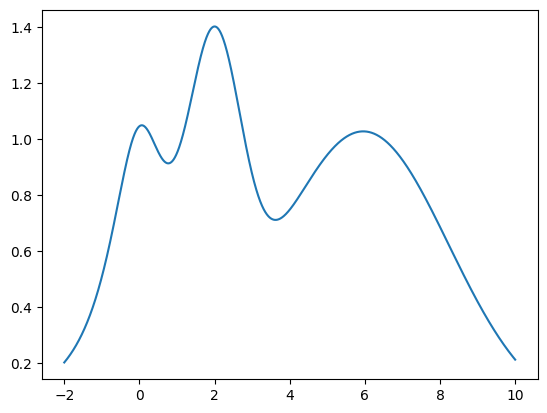

In [ ]:
x = np.linspace(-2, 10, 10000).reshape(-1, 1)
y = target(x)

plt.plot(x, y);

# Create a BayesianOptimization Object
Enter the target function to be maximized, its variable(s) and their corresponding ranges. A minimum number of 2 initial guesses is necessary to kick start the algorithms, these can either be random or user defined.

In [ ]:
acq_function = UpperConfidenceBound(kappa=5)

optimizer = BayesianOptimization(target, {'x': (-2, 10)}, random_state=1,acquisition_function = acq_function)

In this example we will use the Upper Confidence Bound (UCB) as our utility function. It has the free parameter which control the balance between exploration and exploitation; we will set $\kappa =5$  which, in this case, makes the algorithm quite bold.

In [ ]:

optimizer.maximize(init_points=2, n_iter=0)

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8721038 | 3.0042640 |
| 2         | 0.9815404 | 6.6438939 |


Plotting and visualizing the algorithm at each step
Let's first define a couple functions to make plotting easier

In [ ]:
def posterior(optimizer, x_obs, y_obs, grid):
    optimizer._gp.fit(x_obs, y_obs)

    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y):
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        'Gaussian Process and Utility Function After {} Steps'.format(steps),
        fontdict={'fontsize':30}
    )

    #gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    #axis = plt.subplot(gs[0])
    #acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    mu, sigma = posterior(optimizer, x_obs, y_obs, x)
    plt.plot(x, y, linewidth=3, label='Target')
    plt.plot(x_obs.flatten(), y_obs, 'D', markersize=8, label=u'Observations', color='r')
    plt.plot(x, mu, '--', color='k', label='Prediction')

    plt.fill(np.concatenate([x, x[::-1]]),
              np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=.6, fc='c', ec='None', label='95% confidence interval')

    plt.xlim((-2, 10))
    plt.ylim((None, None))
    plt.ylabel('f(x)', fontdict={'size':20})
    plt.xlabel('x', fontdict={'size':20})

    plt.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.)


# Two random points
After we probe two points at random, we can fit a Gaussian Process and start the bayesian optimization procedure. Two points should give us a uneventful posterior with the uncertainty growing as we go further from the observations.

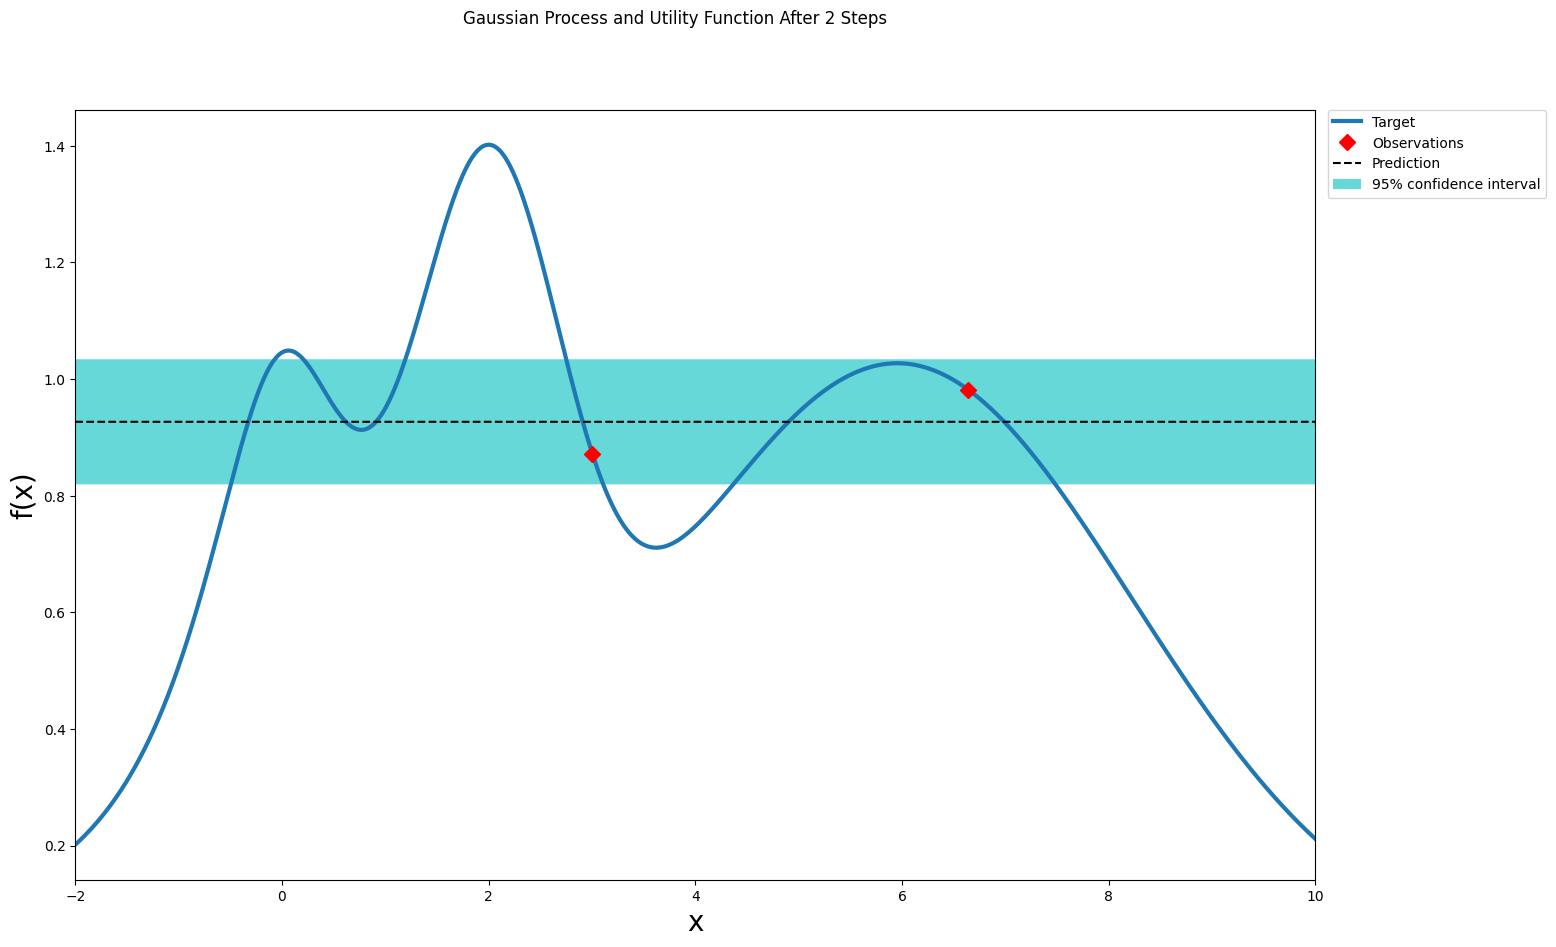

In [ ]:
plot_gp(optimizer, x, y)

# After one step of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.9878704 | 6.5935279 |


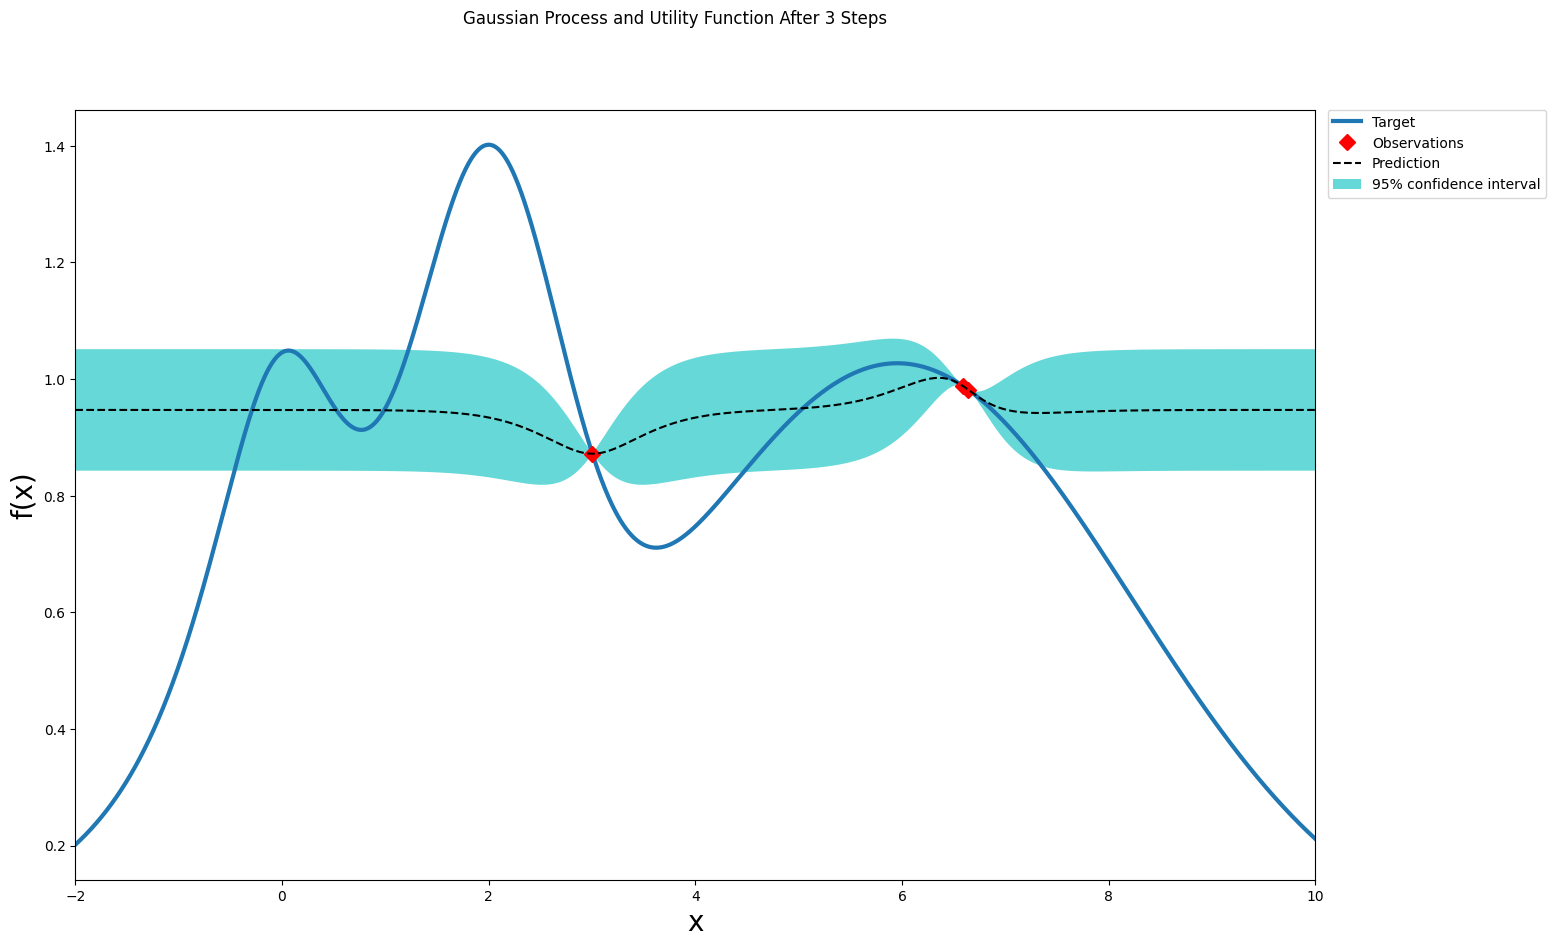

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After two steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 1.0132066 | 5.5740740 |


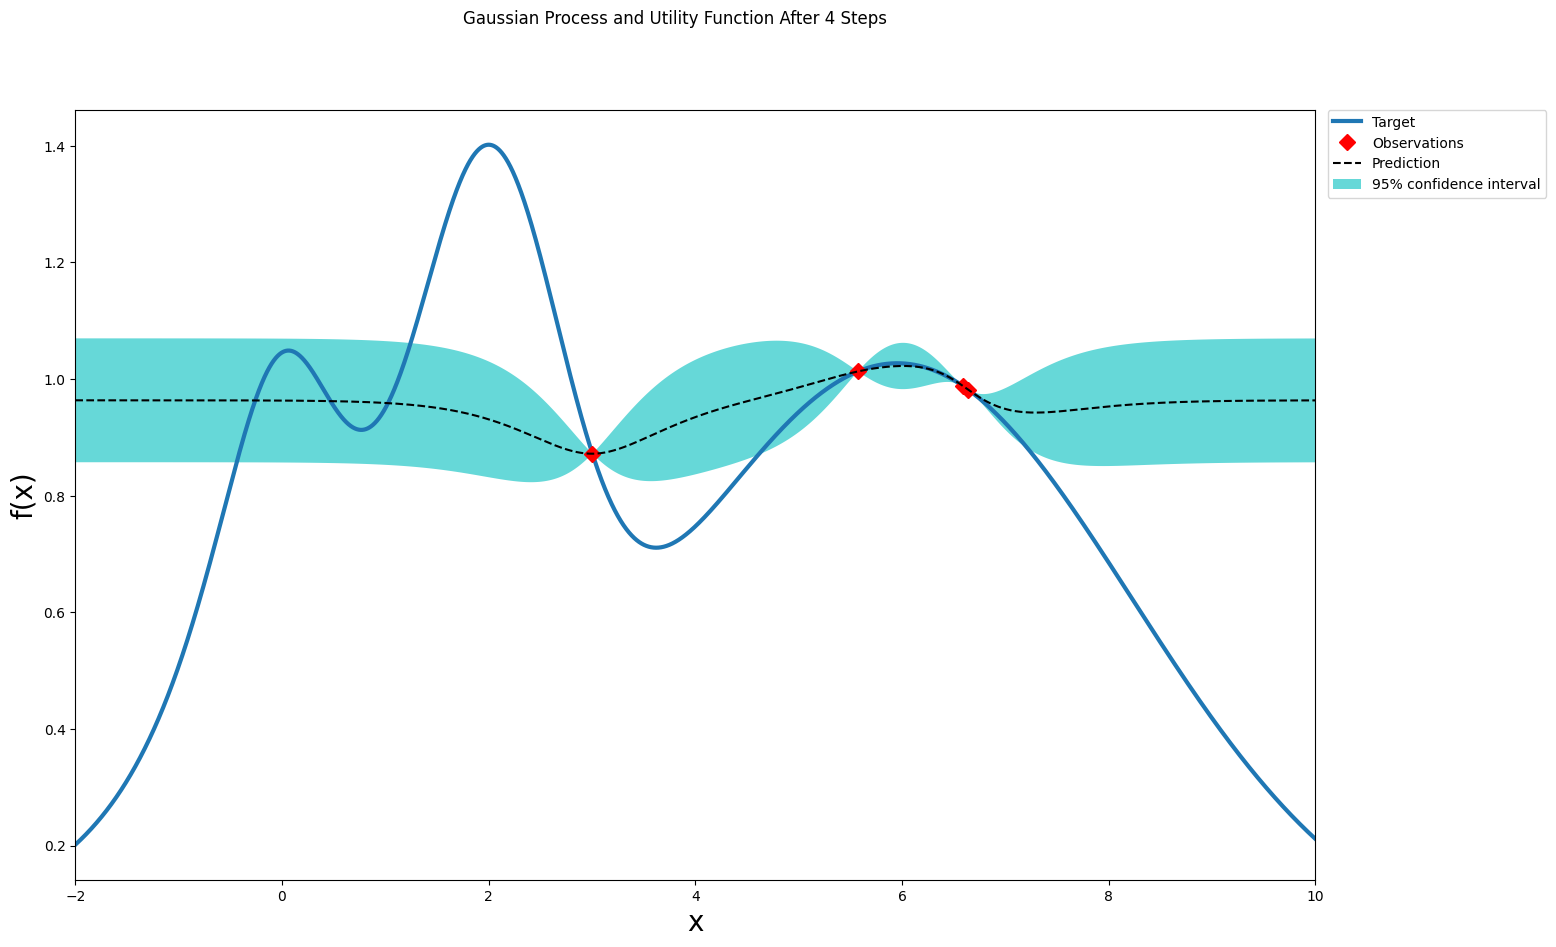

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After three steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 0.2019388 | -1.998297 |


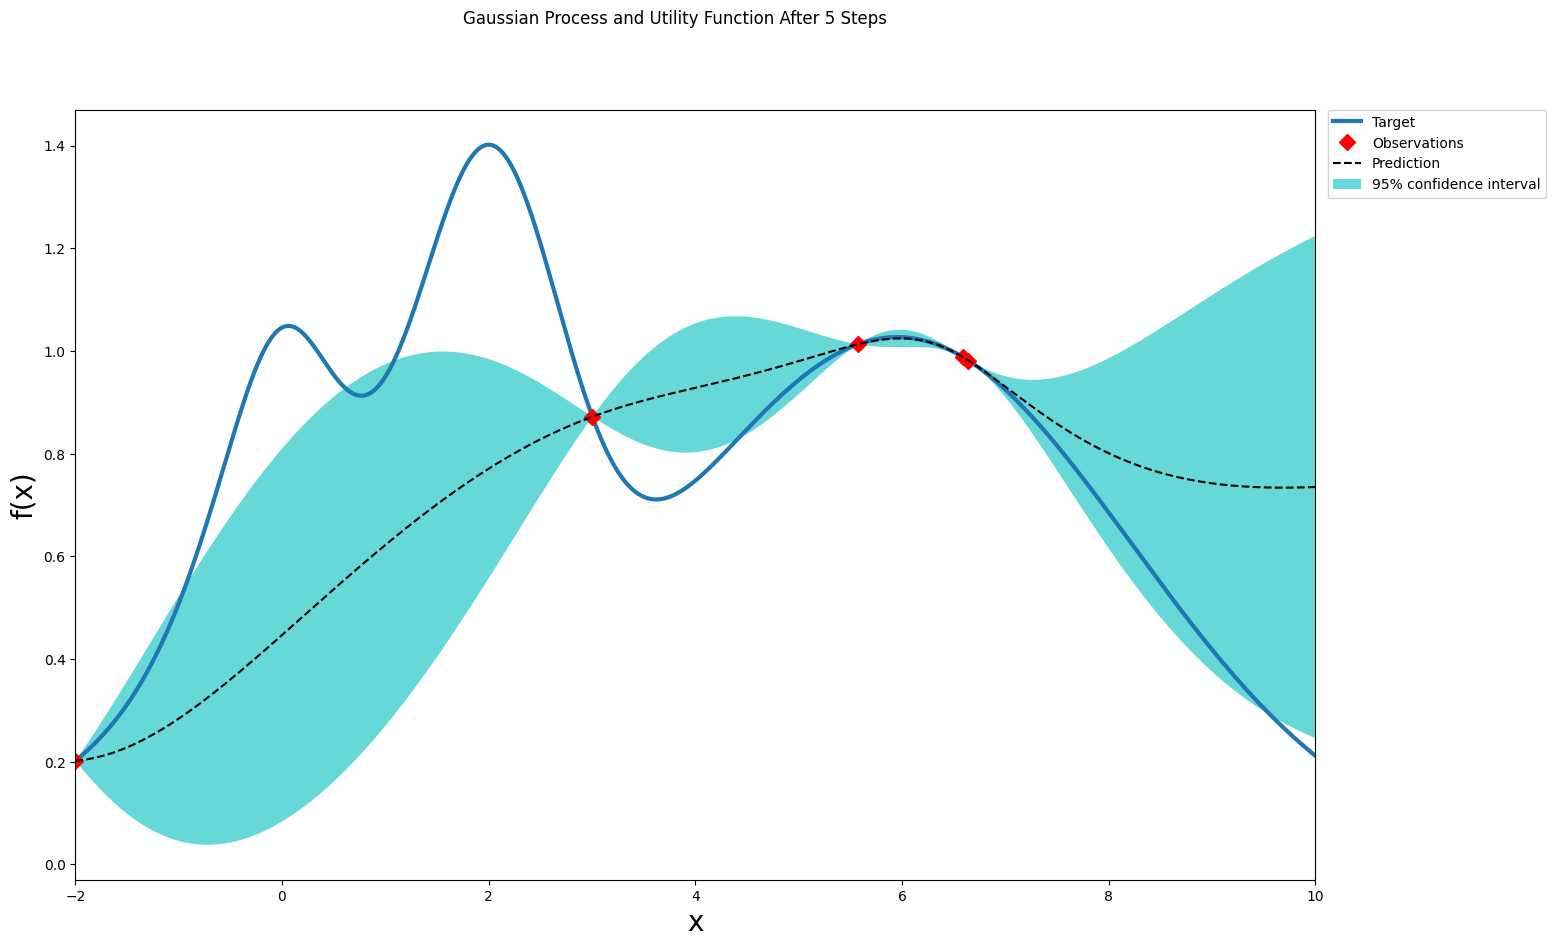

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After four steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 0.2117975 | 10.0      |


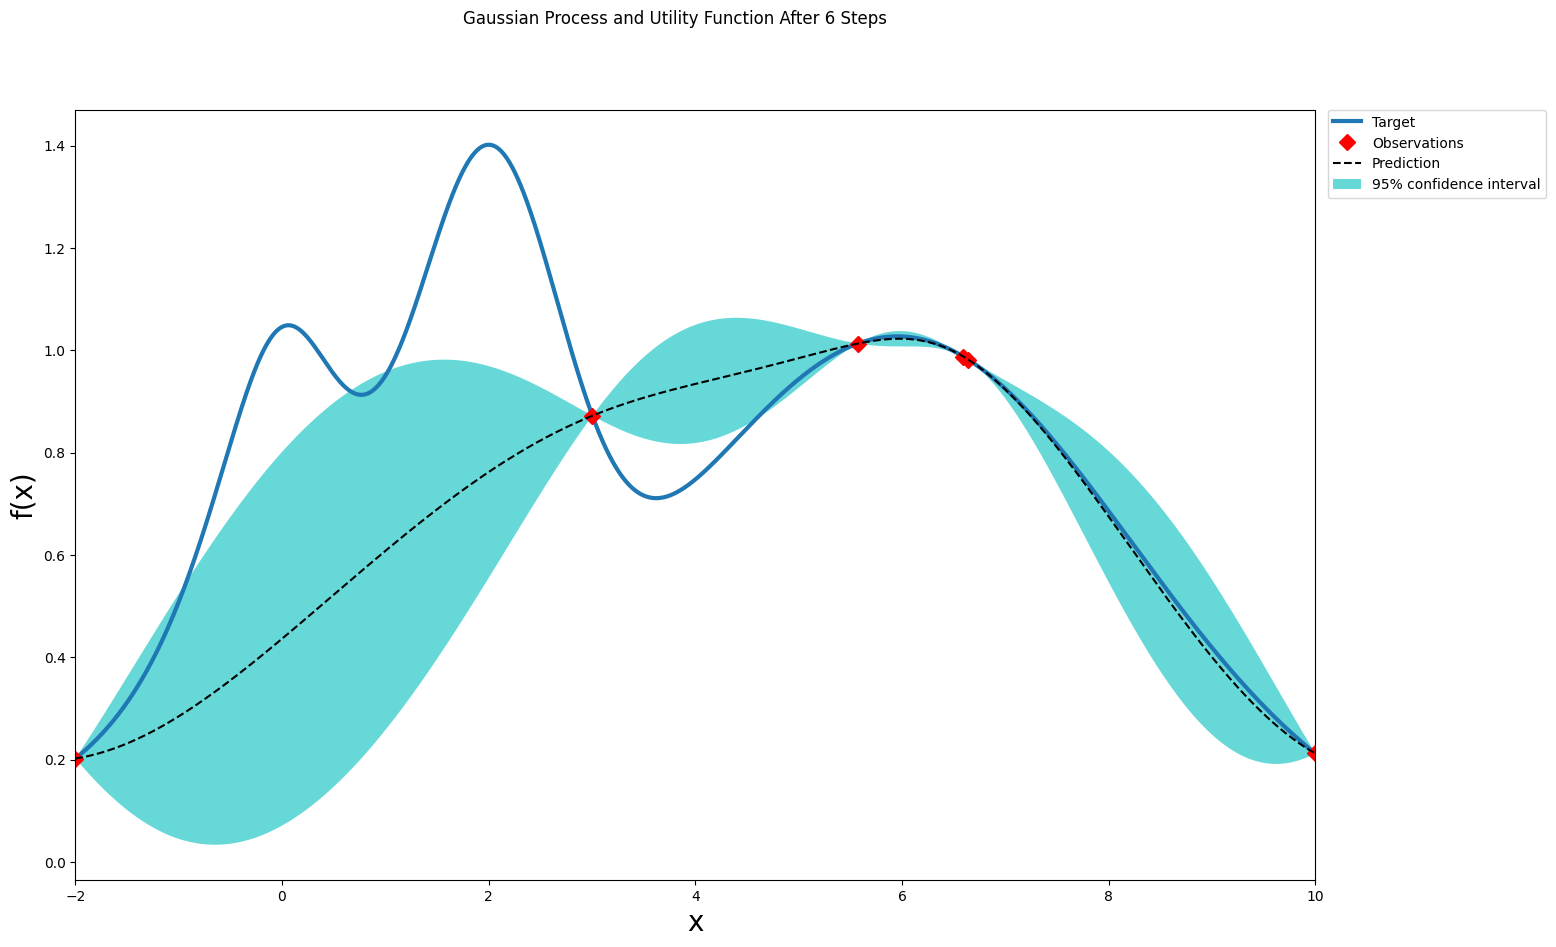

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After five steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 0.9201306 | 0.8706316 |


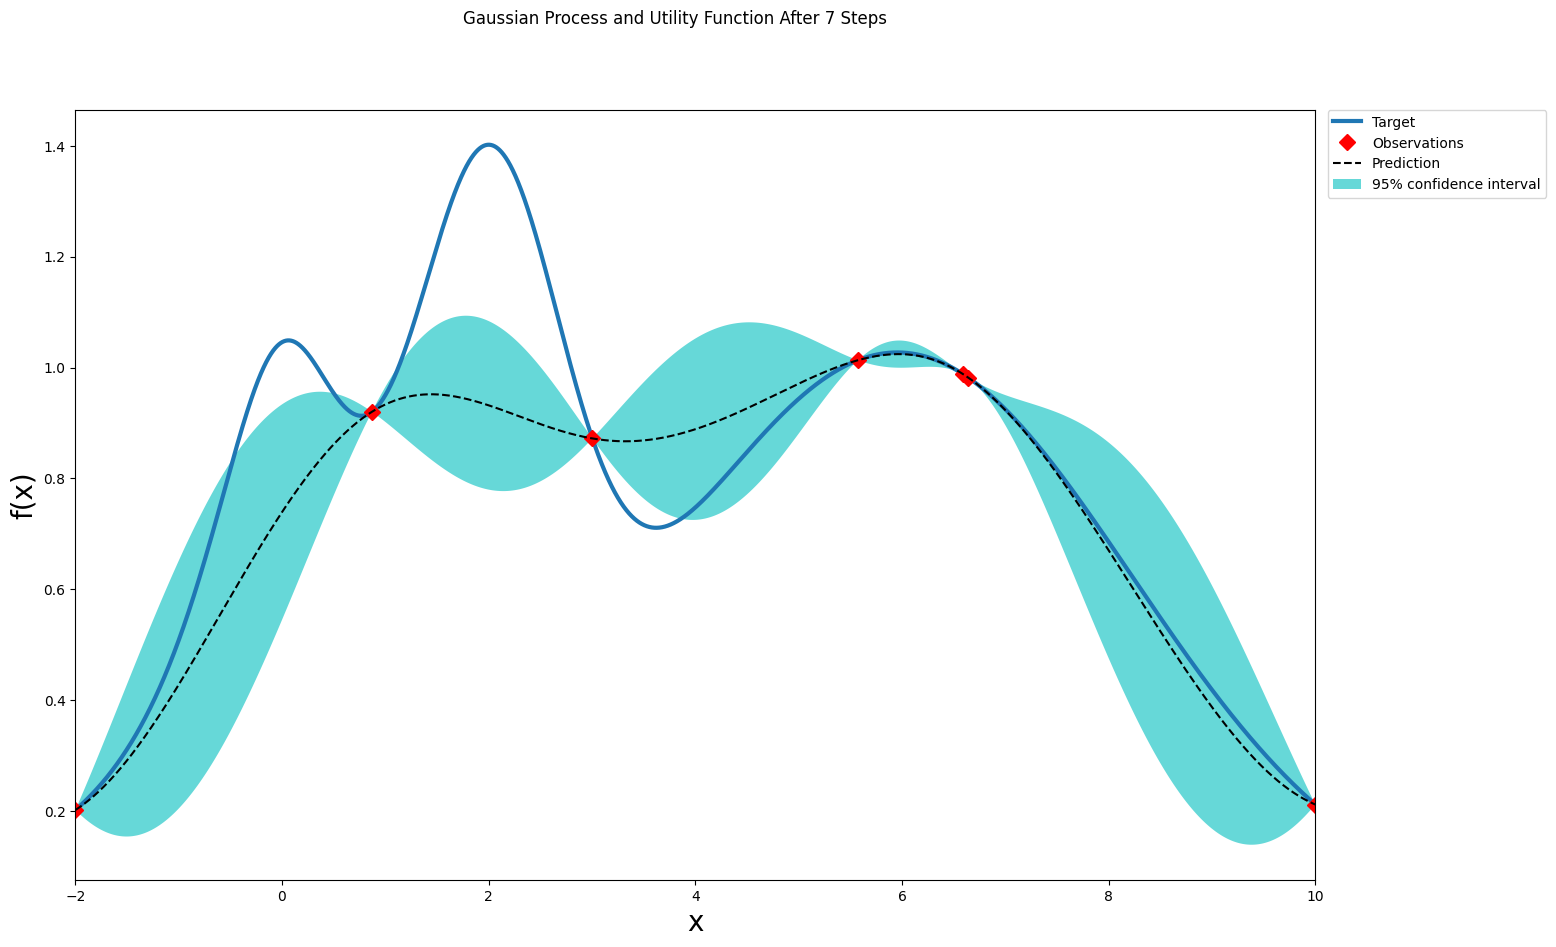

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After six steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 8         | 0.8052774 | 4.2995933 |


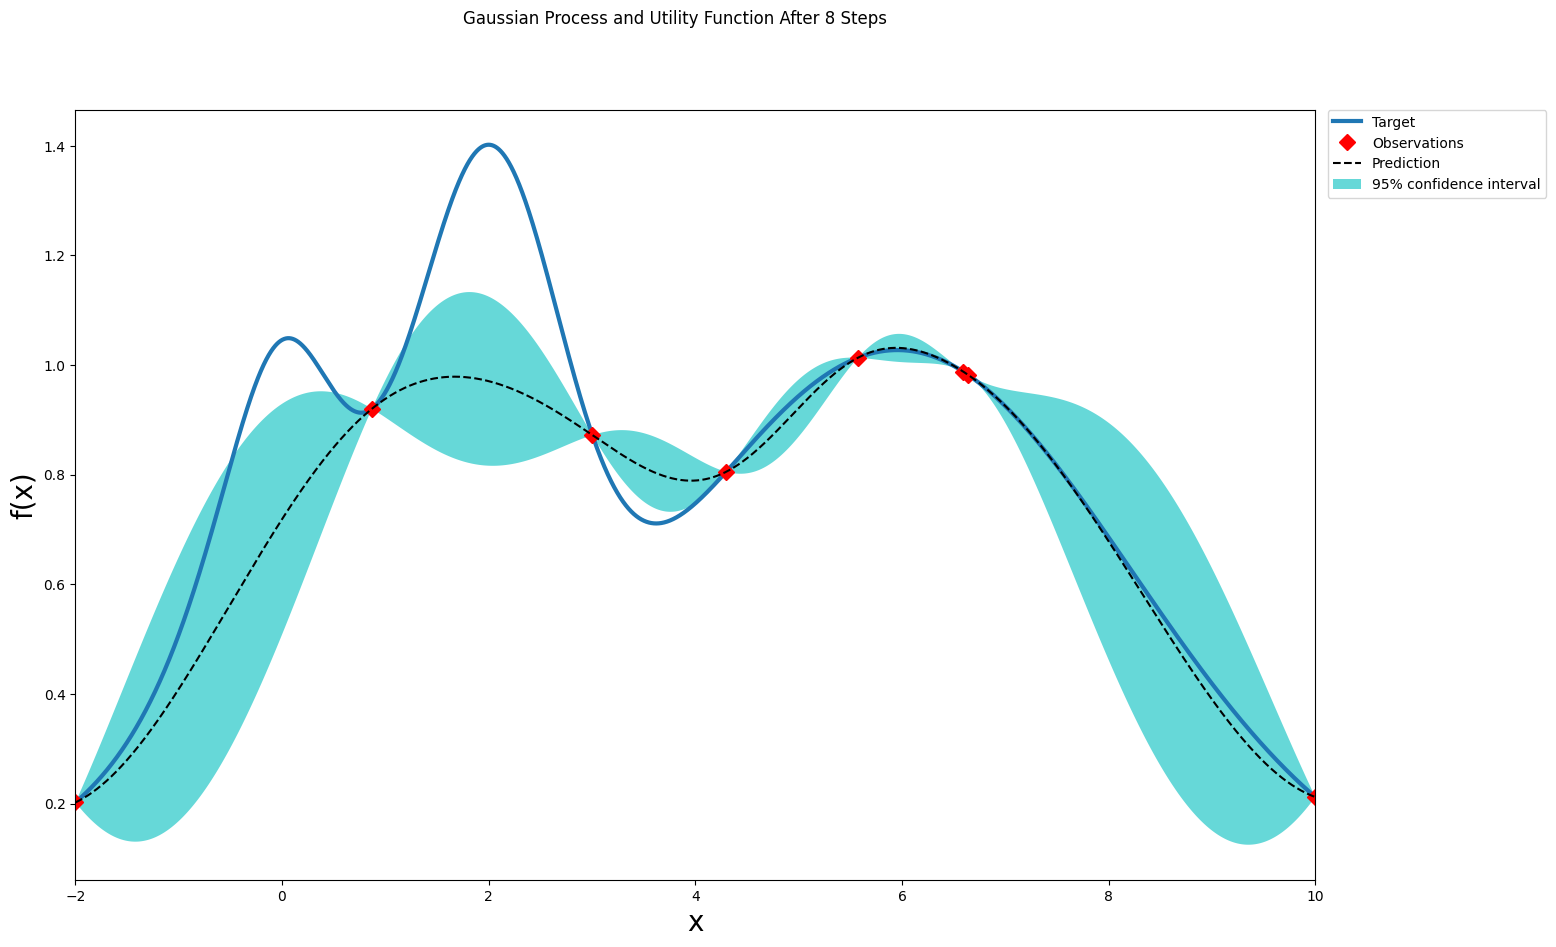

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

# After seven steps of GP (and two random points)

|   iter    |  target   |     x     |
-------------------------------------
| 9         | 1.3821235 | 1.8483924 |


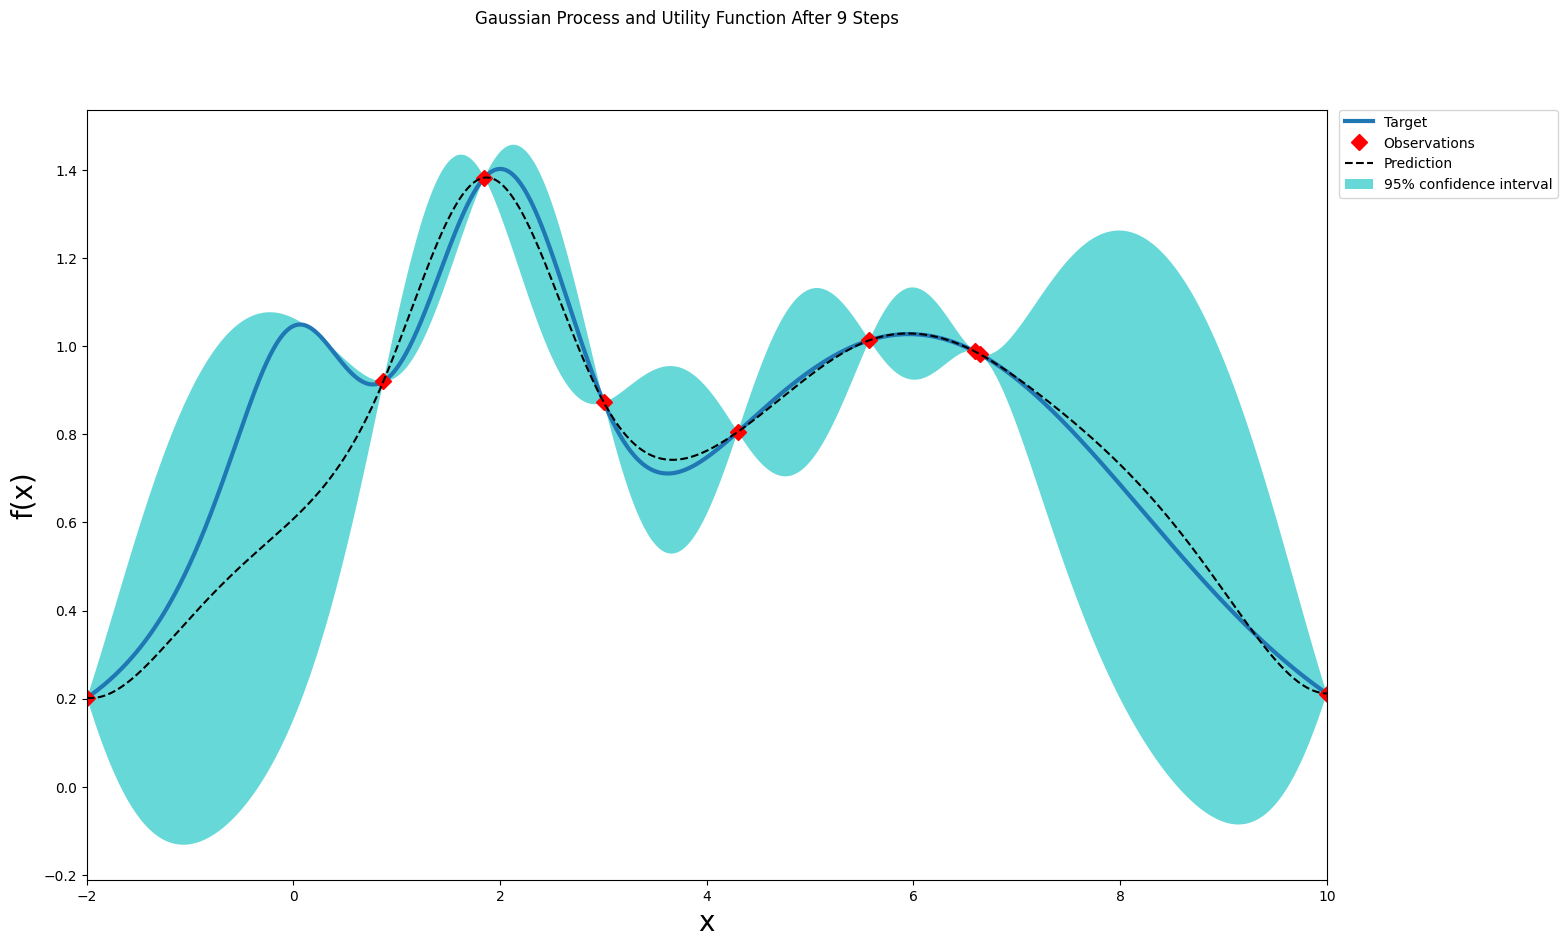

In [ ]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

## Stopping
After just a few points the algorithm was able to get pretty close to the true maximum. It is important to notice that the trade off between exploration (exploring the parameter space) and exploitation (probing points near the current known maximum) is fundamental to a succesful bayesian optimization procedure. The utility function being used here (Upper Confidence Bound - UCB) has a free parameter
 that allows the user to make the algorithm more or less conservative. Additionally, the larger the initial set of random points explored, the less likely the algorithm is to get stuck in local minima due to being too conservative.



|   iter    |  target   |     x     |
-------------------------------------
| 10        | 0.6129076 | 8.2657411 |
| 11        | 0.8511159 | -0.447800 |
| 12        | 1.3276506 | 2.2992103 |
| 13        | 1.2194321 | 1.5015412 |
| 14        | 1.3995004 | 2.0534173 |
| 15        | 1.4012444 | 1.9734242 |
| 16        | 1.4018971 | 2.0009551 |
| 17        | 1.4018970 | 2.0005480 |
| 18        | 1.4018970 | 2.0004270 |
| 19        | 1.4018969 | 2.0004154 |


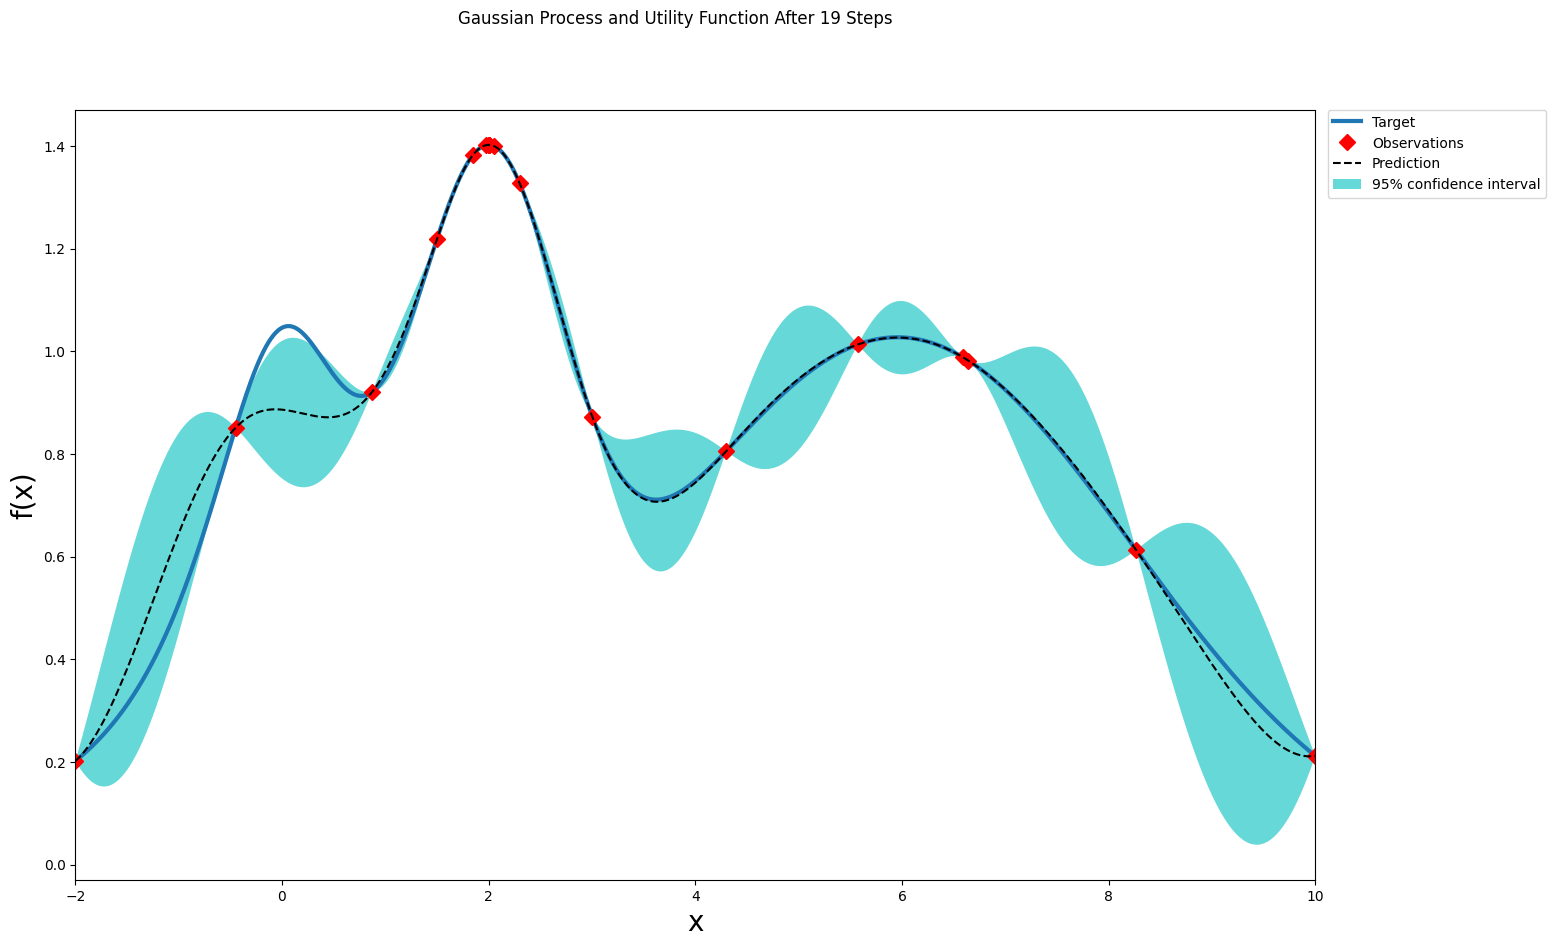

In [ ]:
optimizer.maximize(init_points=0, n_iter=10)
plot_gp(optimizer, x, y)